In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Load dataset (verify the exact path in Kaggle's right-hand panel)
df = pd.read_csv('/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv')
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [10]:
# Drop non-numeric identifier for clustering, but keep it for reference
country_names = df['country']
X = df.drop(columns=['country'])

# Scale features (Crucial for distance-based clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

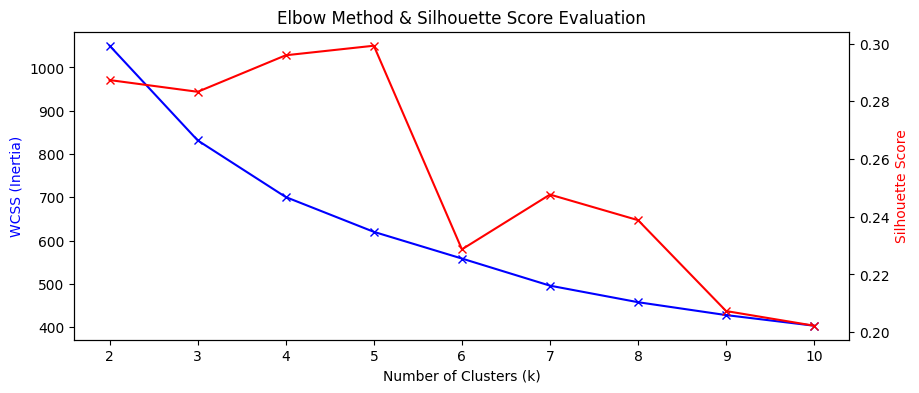

In [11]:
# Find optimal clusters using Elbow Method and Silhouette Score
wcss = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plotting the Elbow and Silhouette metrics
fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(K_range, wcss, 'bx-')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS (Inertia)', color='b')

ax2 = ax1.twinx()
ax2.plot(K_range, silhouette_scores, 'rx-')
ax2.set_ylabel('Silhouette Score', color='r')
plt.title('Elbow Method & Silhouette Score Evaluation')
plt.show()

# Based on plots, choose the optimal k (e.g., k=3)
optimal_k = 3 
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['KMeans_Labels'] = kmeans_final.fit(X_scaled).labels_

In [12]:
# Apply DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=3)
df['DBSCAN_Labels'] = dbscan.fit_predict(X_scaled)

print("DBSCAN Cluster distribution:")
print(df['DBSCAN_Labels'].value_counts())

DBSCAN Cluster distribution:
DBSCAN_Labels
 0    139
-1     25
 1      3
Name: count, dtype: int64


In [13]:
# We use the clean clusters from K-Means as target labels for our Supervised Pipeline
y = df['KMeans_Labels']

# Split data into Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# 1. Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# 2. XGBoost Classifier
xgb_model = XGBClassifier(random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

In [14]:
print("--- Random Forest Performance ---")
print(classification_report(y_test, rf_preds))

print("\n--- XGBoost Performance ---")
print(classification_report(y_test, xgb_preds))

--- Random Forest Performance ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34


--- XGBoost Performance ---
              precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       1.00      0.90      0.95        10
           2       0.89      1.00      0.94        17

    accuracy                           0.94        34
   macro avg       0.96      0.92      0.94        34
weighted avg       0.95      0.94      0.94        34



In [15]:
# Group the original (unscaled) data by the K-Means labels to see the average stats per cluster
cluster_profile = df.groupby('KMeans_Labels').mean(numeric_only=True)
print(cluster_profile)

               child_mort    exports    health    imports        income  \
KMeans_Labels                                                             
0                5.000000  58.738889  8.807778  51.491667  45672.222222   
1               92.961702  29.151277  6.388511  42.323404   3942.404255   
2               21.927381  40.243917  6.200952  47.473404  12305.595238   

               inflation  life_expec  total_fer          gdpp  DBSCAN_Labels  
KMeans_Labels                                                                 
0               2.671250   80.127778   1.752778  42494.444444      -0.222222  
1              12.019681   59.187234   5.008085   1922.382979      -0.234043  
2               7.600905   72.814286   2.307500   6486.452381      -0.035714  


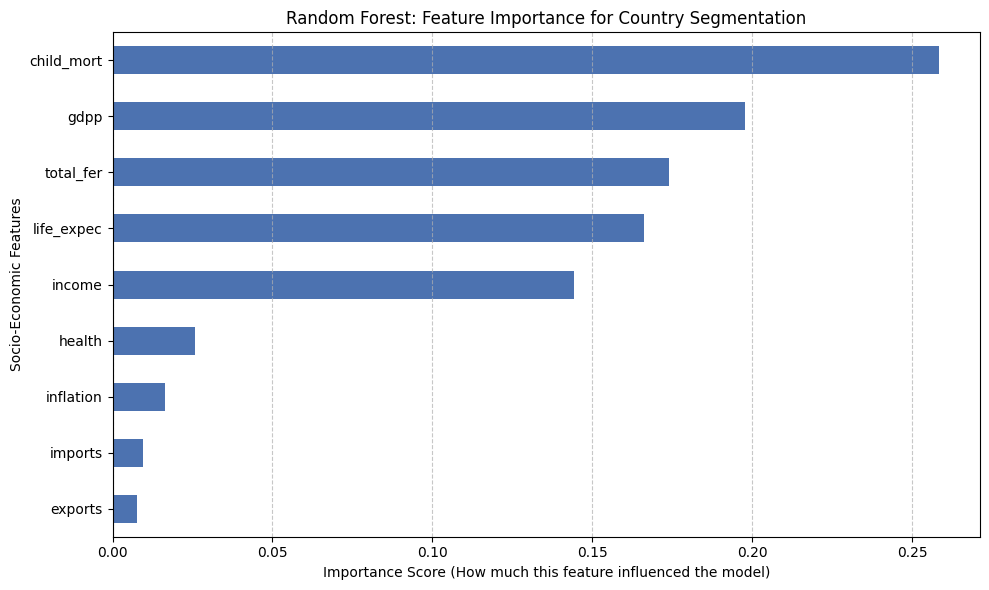

In [16]:
# --- Feature Importance Visualization ---
import matplotlib.pyplot as plt
import pandas as pd

# Extract feature importances from the trained Random Forest model
importances = pd.Series(rf_model.feature_importances_, index=X.columns)

# Sort them for better visualization
importances_sorted = importances.sort_values(ascending=True)

# Plotting
plt.figure(figsize=(10, 6))
importances_sorted.plot(kind='barh', color='#4C72B0')
plt.title('Random Forest: Feature Importance for Country Segmentation')
plt.xlabel('Importance Score (How much this feature influenced the model)')
plt.ylabel('Socio-Economic Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

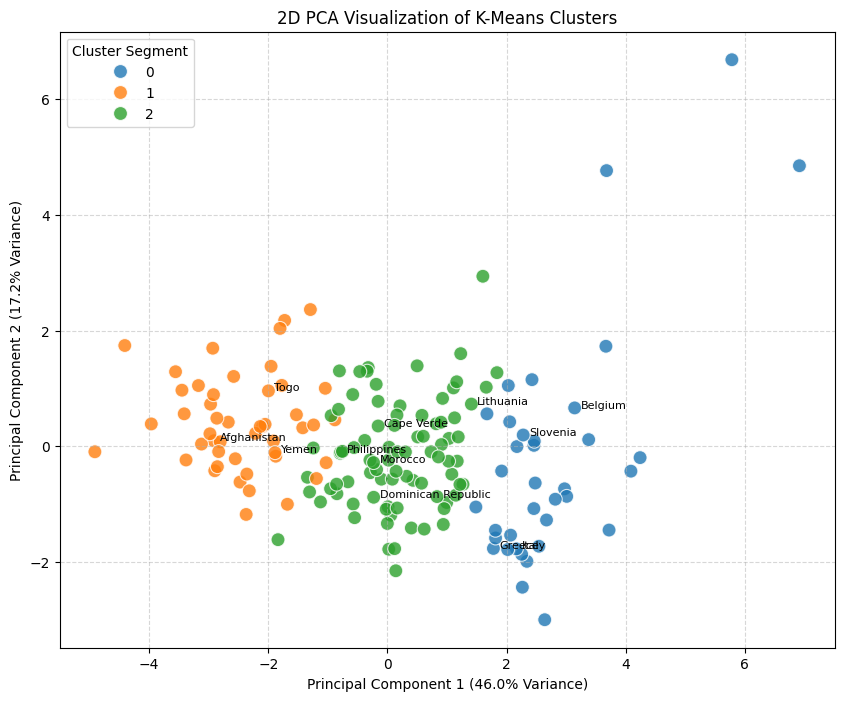

In [17]:
# --- PCA Cluster Visualization ---
from sklearn.decomposition import PCA
import seaborn as sns

# 1. Initialize PCA to reduce our 9 dimensions down to 2
pca = PCA(n_components=2)

# 2. Fit and transform the scaled data
X_pca = pca.fit_transform(X_scaled)

# 3. Create a new DataFrame specifically for plotting
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df['KMeans_Labels'] # Attach your K-Means labels
pca_df['Country'] = country_names # Attach country names (defined in your cell 4)

# 4. Plot the 2D scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='Cluster', 
    palette=['#1f77b4', '#ff7f0e', '#2ca02c'], # Distinct colors for 3 clusters
    data=pca_df, 
    s=100, 
    alpha=0.8
)

# Optional: Annotate a few extreme data points to see where specific countries landed
for i in range(0, pca_df.shape[0], 15): # Annotates every 15th country to avoid clutter
    plt.text(
        pca_df['PC1'][i] + 0.1, 
        pca_df['PC2'][i], 
        pca_df['Country'][i], 
        fontsize=8
    )

# Formatting the plot
plt.title('2D PCA Visualization of K-Means Clusters')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
plt.legend(title='Cluster Segment')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()